In [ ]:
#Research Question
#impact of study time on grades
#In this project, we aim to investigate whether study time influences grades using real-world data.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


## 1. Data Loading
Load your dataset using Python (CSV or JSON)

In [3]:
df_prev = pd.read_csv("student-por.csv")
df = pd.DataFrame(df_prev)

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


## 2. Data Cleaning
Handle missing values by removing rows or filling values with mean median or mode. 
Explain your choice.

In [4]:
df.isna().sum()

i = 0
for d in df['G3']:
    if d == 0:
        df.loc[i, 'G3'] = df['G3'].median(axis=0)
    i += 1
print(df.iloc[163])
print(df.iloc[486])

school            GP
sex                M
age               18
address            U
famsize          LE3
Pstatus            T
Medu               1
Fedu               1
Mjob           other
Fjob           other
reason        course
guardian      mother
traveltime         1
studytime          1
failures           2
schoolsup         no
famsup            no
paid              no
activities        no
nursery          yes
higher            no
internet         yes
romantic         yes
famrel             2
freetime           3
goout              5
Dalc               2
Walc               5
health             4
absences           0
G1                11
G2                 9
G3                12
Name: 163, dtype: object
school              MS
sex                  F
age                 16
address              U
famsize            GT3
Pstatus              T
Medu                 2
Fedu                 2
Mjob             other
Fjob          services
reason          course
guardian        father
travel

## 3. Descriptive Statistics
Compute and explain:
- Mean
- Median
- Variance
- Standard deviation
- Group statistics

In [9]:
#all g's refer to grades
#all s's refer to study time
mean_g = 0
mean_s = 0
med_g = 0
med_s = 0
var_g = 0
var_s = 0
std_g = 0
std_s = 0
gs_g = 0
gs_s = 0
count = 649

for grade in df['G3']:
    mean_g += grade
mean_g = round(mean_g/count, 2)


for study in df['studytime']:
    mean_s += study
mean_s = round(mean_s/count, 2)

med_s = df['studytime'].median(axis=0)
med_g = df['G3'].median(axis=0)


var_s = round(df['studytime'].var(), 2)
var_g = round(df['G3'].var(), 2)

std_g = round(df['G3'].std(), 2)
std_s = round(df['studytime'].std(), 2)



print('Grade Mean:', mean_g)
print('Study Time Mean:', mean_s)
print('Grade Median:', med_g)
print('Study Time Median:', med_s)
print('Grade Variance:', var_g)
print('Study Time Variance', var_s)
print('Grade Standard Deviation:', std_g)
print('Study Time Standard Deviation:', std_s)
a = df.groupby('studytime')['G1'].mean()
print(a)
b = df.groupby('studytime')['G2'].mean()
print(b)
c = df.groupby('studytime')['G3'].mean()
print(c)



#-----

''' ABSENSES '''
print("\n\nMinimum Absences", df['absences'].min())

print("Maximum Absences", df['absences'].max())

print("Mean Absences", df['absences'].mean())

print("Median Absences", df['absences'].median())

print("Standard Deviation in Absences", df['absences'].std())

Grade Mean: 12.18
Study Time Mean: 1.93
Grade Median: 12.0
Study Time Median: 2.0
Grade Variance: 7.08
Study Time Variance 0.69
Grade Standard Deviation: 2.66
Study Time Standard Deviation: 0.83
studytime
1    10.504717
2    11.537705
3    12.422680
4    12.771429
Name: G1, dtype: float64
studytime
1    10.702830
2    11.662295
3    12.793814
4    12.628571
Name: G2, dtype: float64
studytime
1    11.297170
2    12.367213
3    13.226804
4    13.057143
Name: G3, dtype: float64


Minimum Absences 0
Maximum Absences 32
Mean Absences 3.6594761171032357
Median Absences 2.0
Standard Deviation in Absences 4.640758808397126


## 4. Data Visualization
Create at least:
- Bar plot
- Histogram
- Scatter plot

All plots must include titles and axis labels.

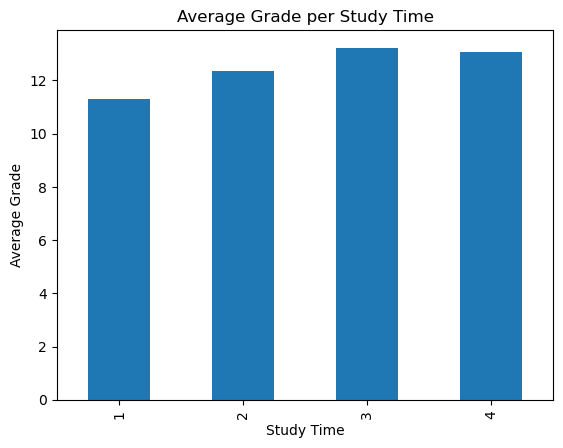

In [10]:
#bar plot
avg_grades = df.groupby('studytime')['G3'].mean()

avg_grades.plot(kind='bar')
plt.title('Average Grade per Study Time')
plt.xlabel('Study Time')
plt.ylabel('Average Grade')

plt.show()



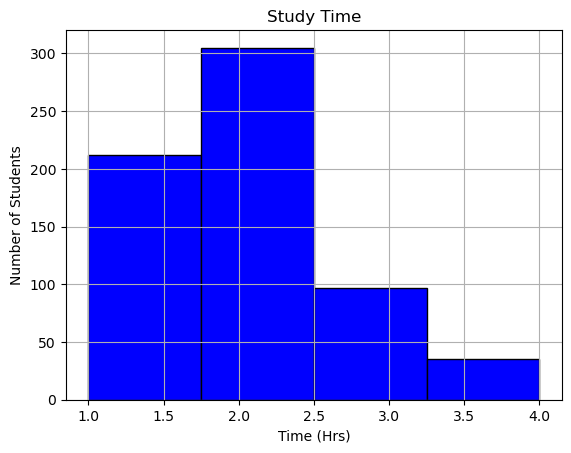

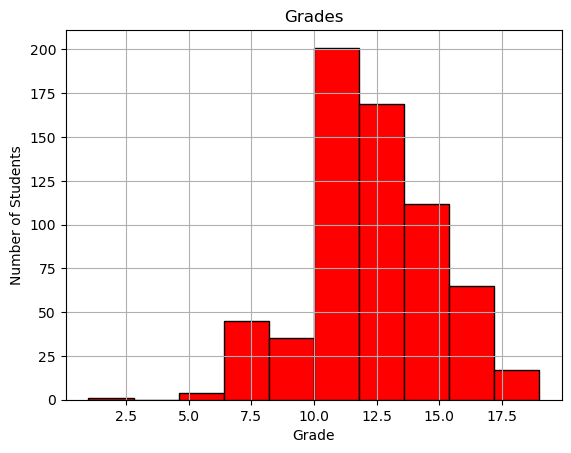

In [11]:
#histogram
df['studytime'].hist(bins=4, color='blue', edgecolor='black')
plt.title('Study Time')
plt.xlabel('Time (Hrs)')
plt.ylabel('Number of Students')
plt.show()

df['G3'].hist(color='red', edgecolor='black')
plt.title('Grades')
plt.xlabel('Grade')
plt.ylabel('Number of Students')
plt.show()


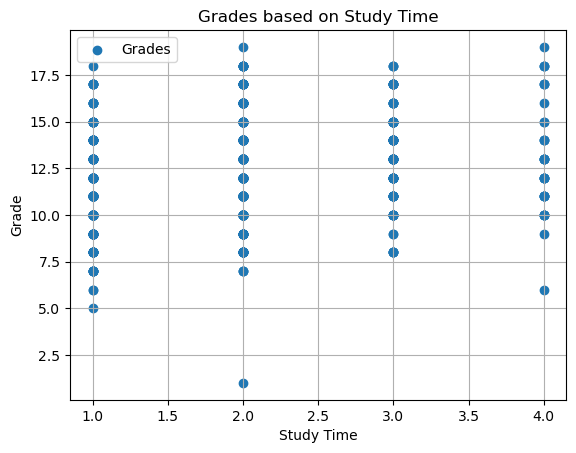

In [12]:
#scatter
G = np.array(df['G3'])
ST = np.array(df['studytime'])
plt.scatter(ST, G, label='Grades')
plt.title('Grades based on Study Time')
plt.xlabel('Study Time')
plt.ylabel('Grade')
plt.legend()
plt.grid(True)
plt.show()


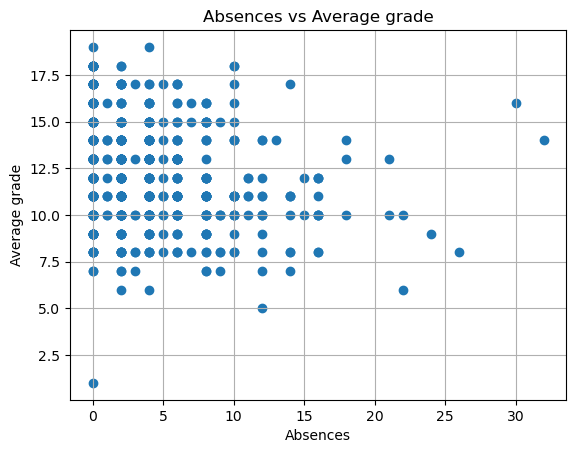

In [13]:
#scatter
plt.scatter(df['absences'], df['G3'])
plt.title('Absences vs Average grade')
plt.xlabel('Absences')
plt.ylabel('Average grade')
plt.grid(True)

plt.show()


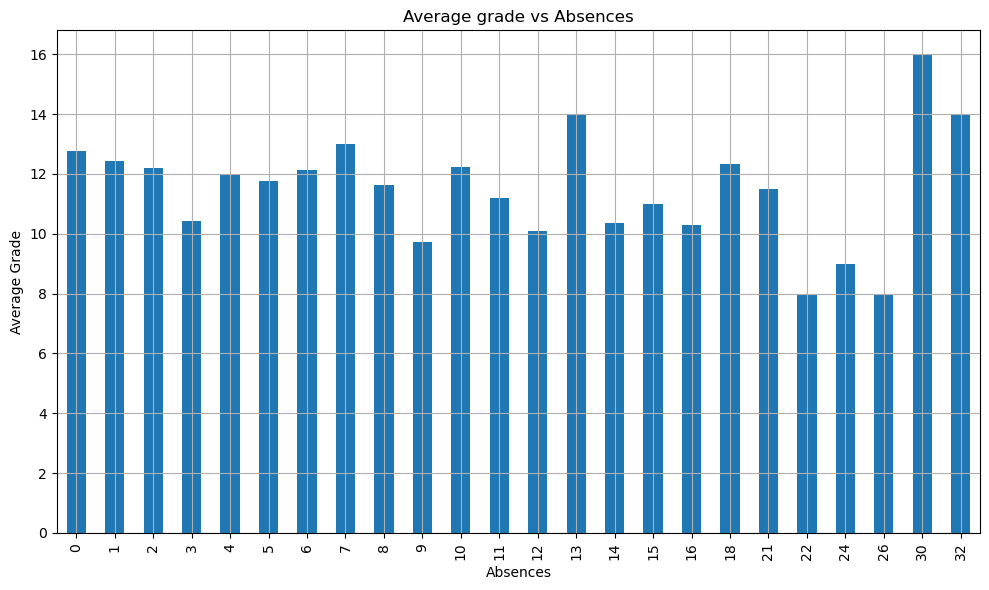

In [14]:
#barplot
grouped = df.groupby('absences')['G3'].mean()

plt.figure(figsize=(10,6))
grouped.plot(kind='bar')
plt.xlabel('Absences')
plt.ylabel('Average Grade')
plt.title('Average grade vs Absences')

plt.grid(True)

plt.tight_layout()
plt.show()

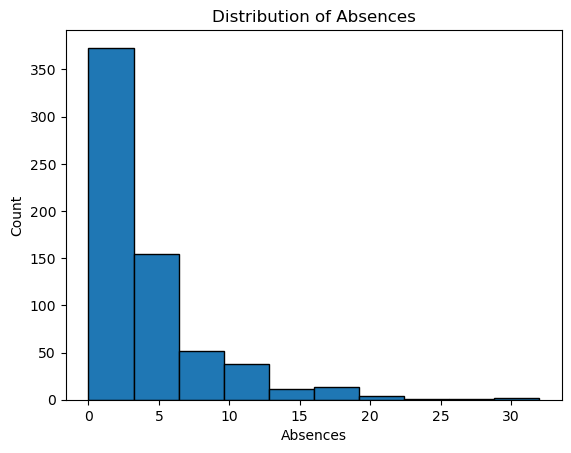

In [15]:
#histogram

plt.hist(df['absences'], bins=10, edgecolor='black')

plt.title('Distribution of Absences')
plt.xlabel('Absences')
plt.ylabel('Count')

plt.show()

## 5. Linear Regression
Use regression to answer a predictive question and explain:
- Inputs (X)
- Output (y)
- Interpretation of results


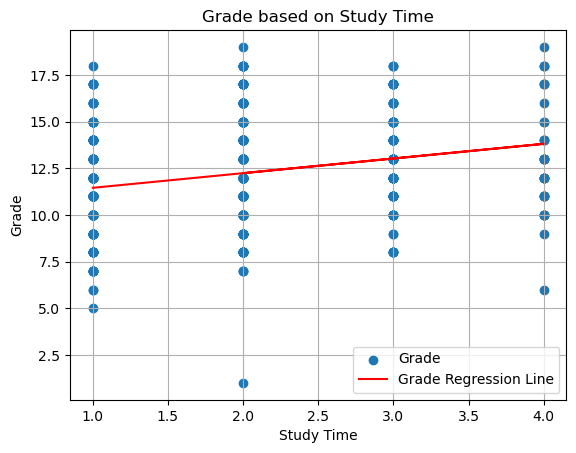

In [16]:
g = np.array(df['G3'])
st = np.array(df['studytime'])
g_reg = stats.linregress(st, g)

plt.scatter(st, g, label='Grade')
plt.plot(st, g_reg.slope*st+g_reg.intercept, label='Grade Regression Line', color = 'red')
plt.title('Grade based on Study Time')
plt.xlabel('Study Time')
plt.ylabel('Grade')
plt.legend()
plt.grid(True)
plt.show()

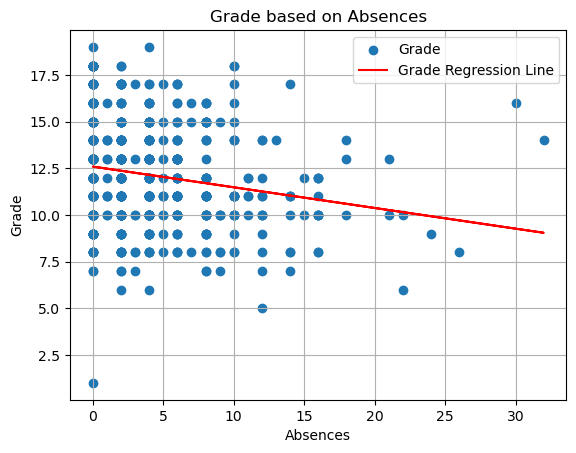

In [17]:
g = np.array(df['G3'])
st = np.array(df['absences'])
g_reg = stats.linregress(st, g)

plt.scatter(st, g, label='Grade')
plt.plot(st, g_reg.slope*st+g_reg.intercept, label='Grade Regression Line', color = 'red')
plt.title('Grade based on Absences')
plt.xlabel('Absences')
plt.ylabel('Grade')
plt.legend()
plt.grid(True)
plt.show()

## 6. Machine Learning Model
Use one ML model:
- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors

Explain what you predict, model accuracy, and features used.

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score

x = df['studytime']
x = pd.DataFrame(np.array(x).reshape(-1, 1), columns=['studytime'])
print(x.shape)

y = (df['G3'] >= 10).astype(int) #converts to pass/fail basically
#y = df['G3'].values #added .values here
#y = pd.DataFrame(np.array(y).reshape(-1,1), columns=['G3'])
print(y.shape)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=20)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {round(accuracy, 2)}')

# I know you have this a little lower technically, but here is this as well.
# True Negatives (pred fail, fails)  | False Positives (pred pass, failed)
# False Negatives (pred fail, pass)  | True Positives (pred pass, pass) 
print(confusion_matrix(y_test, y_pred))

(649, 1)
(649,)
Accuracy: 0.87
[[  0  22]
 [  0 141]]


In [30]:
y_pred = model.predict(x_train)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [34]:
#I can't get this to work, but I got it to work up higher ^^
#cm = confusion_matrix(y_test, y_pred)
#cm

In [39]:
#MLM for absences
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

#select data
x = df[['absences']] #double brackets makes 2D?
y = (df['G3'] >= 10).astype(int) #pass fail

#split data into training and test set, 25% for model testing, 75% for model training
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state = 3)

#model development
#instantiate model with default parameters
logreg = LogisticRegression(random_state=3)
#fit model with data
logreg.fit(x_train, y_train)

y_pred = logreg.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {round(accuracy, 2)}')

#confusion matrix
# True Negatives (pred fail, fails)  | False Positives (pred pass, failed)
# False Negatives (pred fail, pass)  | True Positives (pred pass, pass) 
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.9
[[  0  16]
 [  0 147]]
